# **Density Estimation**

In this module, You will learn about Density Estimation and the various types of density estimation

# **Learning Objectives**

By the end of this lesson, all students will be able to

1. Understand about Density Estimation and It's importance

2. Understand about Probability Density

3. Understand about types of Density Estimation


# What is Density Estimation ?
Density estimation is a process where you have a set of randomly sampled data points  obtained from an unknown probability distribution (PDF), and you want to create an estimation of that underlying distribution.




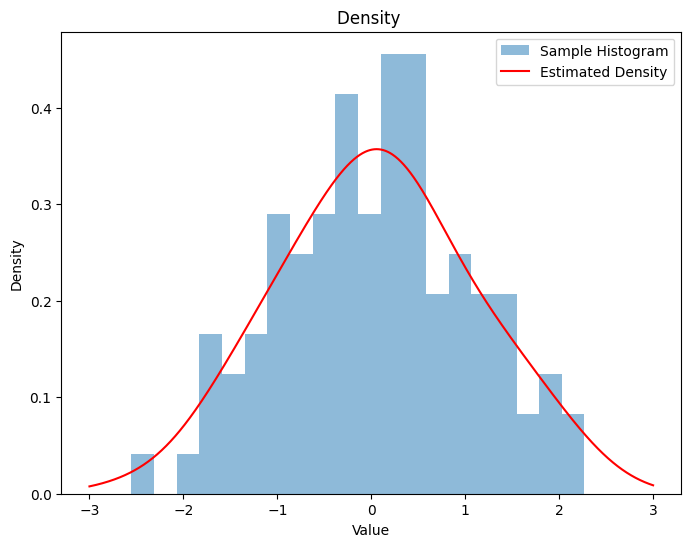

Figure 1 : Example of Density estimation

In Figure 1, The historgarm is a visualization of the sampled data which is obtained from a unknown distribution.The red curve is the estimation we have produced or estimated of that unknown distribution

# **General use of Density Estimation**

Density estimation is a problem encountered in various fields. It involves estimating the probability distribution of data points. For example, in medicine,If we might want to predict the likelihood of a heart attack for a specific age group using medical records. In demographics, we could analyze census data or surveys to understand the geographic distribution of a population. Density estimation is also useful in predicting natural events, like the intervals between geyser eruptions based on past observations.

# **Density Estimation in Deep Unsupervised Learning**

Many deep unsupervised learning methods are used for data generation. Density estimation helps model the underlying data distribution, allowing the generation of new data samples that resemble the training data. For example, in GANs and VAEs, the generator network aims to create data points that follow the estimated data distribution.

Density estimation can be used to learn useful data representations.These represenation can be used in data compression. Autoencoders, for example, learn to encode data into a lower-dimensional space while preserving important information

In conclusion, One of the main goal of Deep Unsupervised learning is to understand the underlying data distribution and Denstity Estimation helps to model the uderlying data distribution







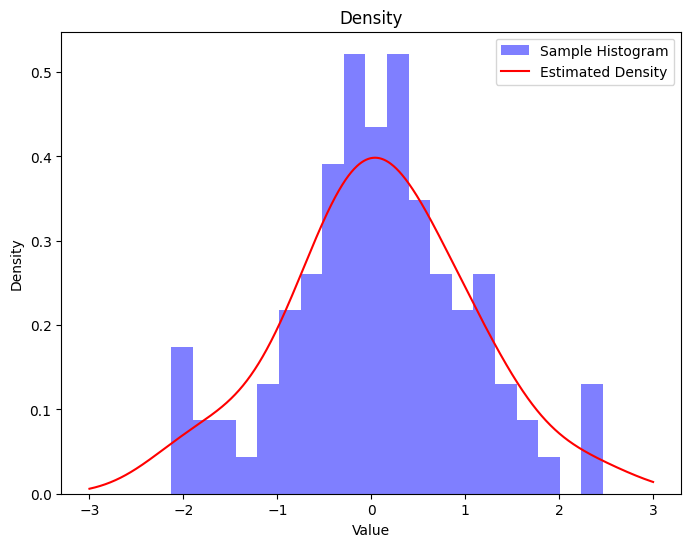

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Generate a random sample from a normal distribution
np.random.seed(10)
sample = np.random.normal(0, 1, 100)

# Create a range of values for which we want to estimate the density
x_values = np.linspace(-3, 3, 1000).reshape(-1, 1)

# Fit a kernel density estimator to the sample data
kde = KernelDensity(bandwidth=0.5, kernel='gaussian')
kde.fit(sample.reshape(-1, 1))

# Estimate the density for the range of values
log_density = kde.score_samples(x_values)
density = np.exp(log_density)

# Plot the original sample and the estimated density with a different histogram color
plt.figure(figsize=(8, 6))
plt.hist(sample, bins=20, density=True, alpha=0.5, label='Sample Histogram', color='blue')  # Change the color to 'blue'
plt.plot(x_values, density, label='Estimated Density', color='red')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.title('Density')
plt.show()


# **Types of Density Estimation**

1. Parametric Density Estimation

2. Non Parametric Density Estimation

# **Parametric Density Estimation**

Parametric density estimation involves fitting a probability distribution to a dataset based on a specific model.
Parametric methods makes a strict prior assumptions about the type of
the underlying density function. For example, a parametric density estimation approach may assume the random variables have a Poisson distribution or the PDF is a polynomial of a particular degree. Such
assumptions decrease the complexity of the problem, since only the parameters of the chosen family of functions need to be determined.

For example, If we assue a underlying distribution follows Normal distribution then all we have to do is find the Mean and Standard Deviation for Density Estimation of the sampled data to estimate the Density



# **Demo of Parametric Density Estimation**

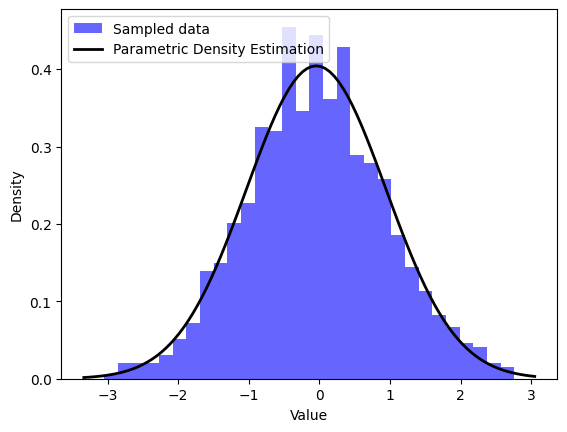

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate some example data
np.random.seed(0)
data = np.random.normal(0, 1, 1000)  # Generate 1000 samples from a standard normal distribution


#Obtain the Mean and Standard Deviation on the data
mu, std = norm.fit(data)

# Plot the histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, color='b', label='Sampled data')

# Create a range of x values for the estimated Normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Calculate the probability density function (PDF) for the estimated Normal distribution
p = norm.pdf(x, mu, std)

# Plot the PDF as a line on top of the histogram
plt.plot(x, p, 'k', linewidth=2, label='Parametric Density Estimation')

# Add labels and a legend to the plot
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.show()

plt.show()


In the above code demo, We are estimating density of the the normally distriubuted data. The steps are

Step 1. First sample data from a underlying distribution. Here we are sampling data from a normal distribution randomly

Step 2. Calculate the Mean and Standard Deviation of the sampled distribution

Step 3. Use the Mean and Standard Deviation to draw a Normal Probability Desnity Function


***Note - Feel free to change the random seed and observe the output***


# **Advantages of parametric density estimation**

1. **Simplicity and Interpretability:** . These model used for parametric density estimation  are simple and interpretable, making it easier to understand and communicate the underlying data distribution.

2. **Efficiency:** Parametric models are computationally efficient, especially when compared to non-parametric methods like kernel density estimation. They require estimating a fixed number of parameters, which can be done quickly, even with large datasets.For example for Normal Distribution all we need is meand and standard deviation for density estimation

3. **Hypothesis Testing and Inference:** Parametric models provide a solid foundation for hypothesis testing and statistical inference. You can perform tests and make inferences about population parameters, such as means, variances, and percentiles, with well-established statistical methods





# **Code Demo that shows how parametric density estimation can be sensitive to assumption**

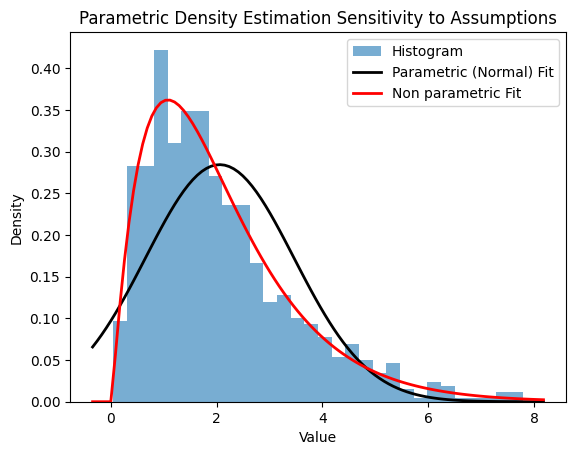

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

# Generate a dataset from a gamma distribution
np.random.seed(42)
data = gamma.rvs(a=2, loc=0, scale=1, size=1000)

# Fit a normal distribution to the data (incorrect assumption)
mu, std = norm.fit(data)

# Create a histogram of the data
plt.hist(data, bins=30, density=True, alpha=0.6, label='Histogram')

# Create a PDF using the estimated normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Parametric (Normal) Fit')

# True gamma PDF for comparison
gamma_params = gamma.fit(data)
pdf_gamma = gamma.pdf(x, *gamma_params)
plt.plot(x, pdf_gamma, 'r', linewidth=2, label='Non parametric Fit')

plt.title('Parametric Density Estimation Sensitivity to Assumptions')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


## **Gaussian Mixture Model**

A Gaussian Mixture Model (GMM) is a probabilistic model used to represent complex probability distributions as a combination of several simpler Gaussian (normal) distributions.


A common issue with parametric models is that they introduce some bias when estimating probability distributions. Even with a lot of data from the same source, we can't perfectly capture the true underlying distribution. However, parametric models are attractive because their parameters have clear interpretations.

To mitigate the bias problem, one approach is to use a mixture of distributions. This means combining multiple simpler distributions to better represent the complex data. This approach helps improve accuracy, especially when working with parametric models.


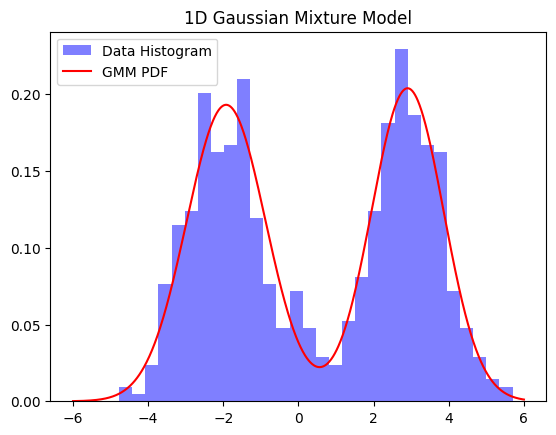

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Generate synthetic 1D data
np.random.seed(0)
data = np.concatenate((np.random.normal(-2, 1, 300), np.random.normal(3, 1, 300)))

# Reshape the data to a 2D array (required for scikit-learn)
data = data.reshape(-1, 1)

# Create and fit a Gaussian Mixture Model with two components
n_components = 2
gmm = GaussianMixture(n_components=n_components, random_state=0)
gmm.fit(data)

# Generate points along the x-axis for plotting
x = np.linspace(-6, 6, 1000)
x = x.reshape(-1, 1)

# Calculate the PDF of the GMM at each point
pdf = np.exp(gmm.score_samples(x))

# Plot the data and the GMM PDF
plt.hist(data, bins=30, density=True, alpha=0.5, color='blue', label='Data Histogram')
plt.plot(x, pdf, color='red', label='GMM PDF')
plt.title('1D Gaussian Mixture Model')
plt.legend()
plt.show()

plt.show()


**Gaussian Mixture Model (GMM):**

- `n_components = 2`: This parameter sets the number of components in the Gaussian Mixture Model. In this case, there are two components, corresponding to the two groups of data points generated in step 1.

- `gmm = GaussianMixture(n_components=n_components, random_state=0)`: This line of code initializes a Gaussian Mixture Model (GMM) object. It specifies the number of components using the `n_components` parameter, and `random_state=0` is set for reproducibility. The GMM object is now ready to be fitted to the data to learn the underlying Gaussian distributions.

- `gmm.fit(data)`: This command fits the Gaussian Mixture Model to the 1D data. In practical terms, it means that the GMM is learning the parameters of Gaussian distributions that best describe the dataset. These parameters include the means, variances, and mixing coefficients for the two Gaussian components. The GMM is essentially learning how to represent the data as a combination of two Gaussian distributions, providing a probabilistic modeling of the data's underlying structure.

**PDF Calculation:**

- `pdf = np.exp(gmm.score_samples(x)`: This calculates the PDF of the GMM at each point in the x array. The score_samples method calculates the log likelihood of the data points. Taking the exponential of these log likelihoods gives the PDF.





## **Some Prombles with Gaussian Mixture Model**

Although the GMM or other mixture model have these good advantages, there are three serious issues about
them.

**Identifiability Problem:**

In mixture models with multiple components, it's possible to have different parameter sets that describe the same distribution. For instance, two sets of parameters can represent the same mixture of Gaussians.

**Computation Problem:**

Finding the Maximum Likelihood Estimate (MLE) for mixture model parameters can be difficult because it often involves non-convex likelihood functions with many local optima. Numerical methods like gradient descent or the EM algorithm are used, but they don't guarantee finding the true MLE.

**Choice of K:**

Selecting the right number of components (K) in a mixture model is complex. Unlike nonparametric methods, there's no straightforward way to determine the optimal K. It often requires model selection techniques to make this choice.


# **Disadvantages of Parametric density estimation**

**1.Sensitivity to Assumptions:** Parametric density estimation relies on the assumption that the data follows a specific probability distribution (e.g., Gaussian, Poisson). If this assumption is incorrect, the model may produce biased or inaccurate results. In practice, data often deviates from ideal distributions, and model performance can suffer as a result.

**2.Limited Flexibility:** Parametric models have fixed functional forms determined by the chosen distribution(Normal Distribution , Poission Distribution). If the data's true underlying distribution is complex or unknown, parametric models may struggle to capture it accurately.

**3.Outliers and Skewed Data:** Parametric modelss may not perform well on data with extreme values or highly skewed distributions. These data points can have a significant impact on parameter estimates.

## **Choosing Theoretical Distribution for Parametric Density Estimation**



### **Q-Q Plots**
The QQ plot, or quantile-quantile plot, is a graphical tool to help us assess if a set of data plausibly came from some theoretical distribution such as a normal or exponential



1. Data Sorting: Start by sorting your dataset in ascending order. This is crucial for calculating quantiles.



2. Quantile Calculation: Calculate the quantiles of your dataset. Quantiles are values that divide your data into equally sized parts, typically expressed as percentiles. For example, the median corresponds to the 50th percentile.



3. Theoretical Quantiles: Calculate the theoretical quantiles based on the assumed distribution you want to test. For instance, if you're assessing normality, you'd compute the quantiles for the standard normal distribution (mean = 0, standard deviation = 1).



4. Plotting: Create a scatterplot where the x-axis represents the quantiles of your dataset, and the y-axis represents the quantiles of the assumed distribution.

5. Interpretation:If your data conforms to the assumed distribution, the points on the Q-Q plot will closely align along a diagonal line, often a straight line.
Deviations from the diagonal line indicate differences between your data and the assumed distribution. Points above the line suggest heavier tails (right-skewed data), while points below the line indicate lighter tails (left-skewed data).
Significant departures from the diagonal line suggest that your data does not follow the assumed distribution.


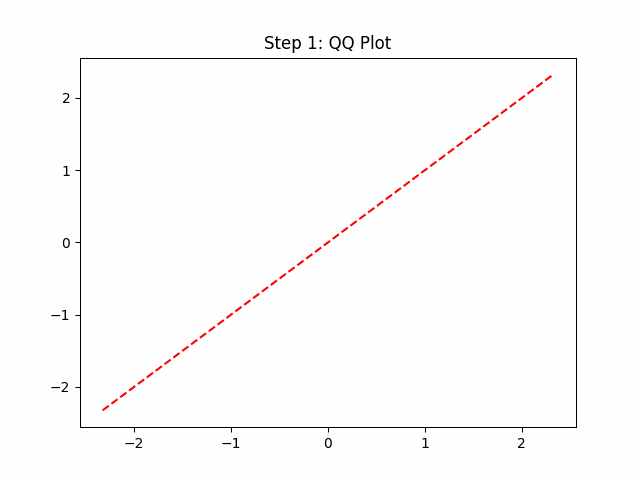

### **Q-Q plots for different Types of Data**

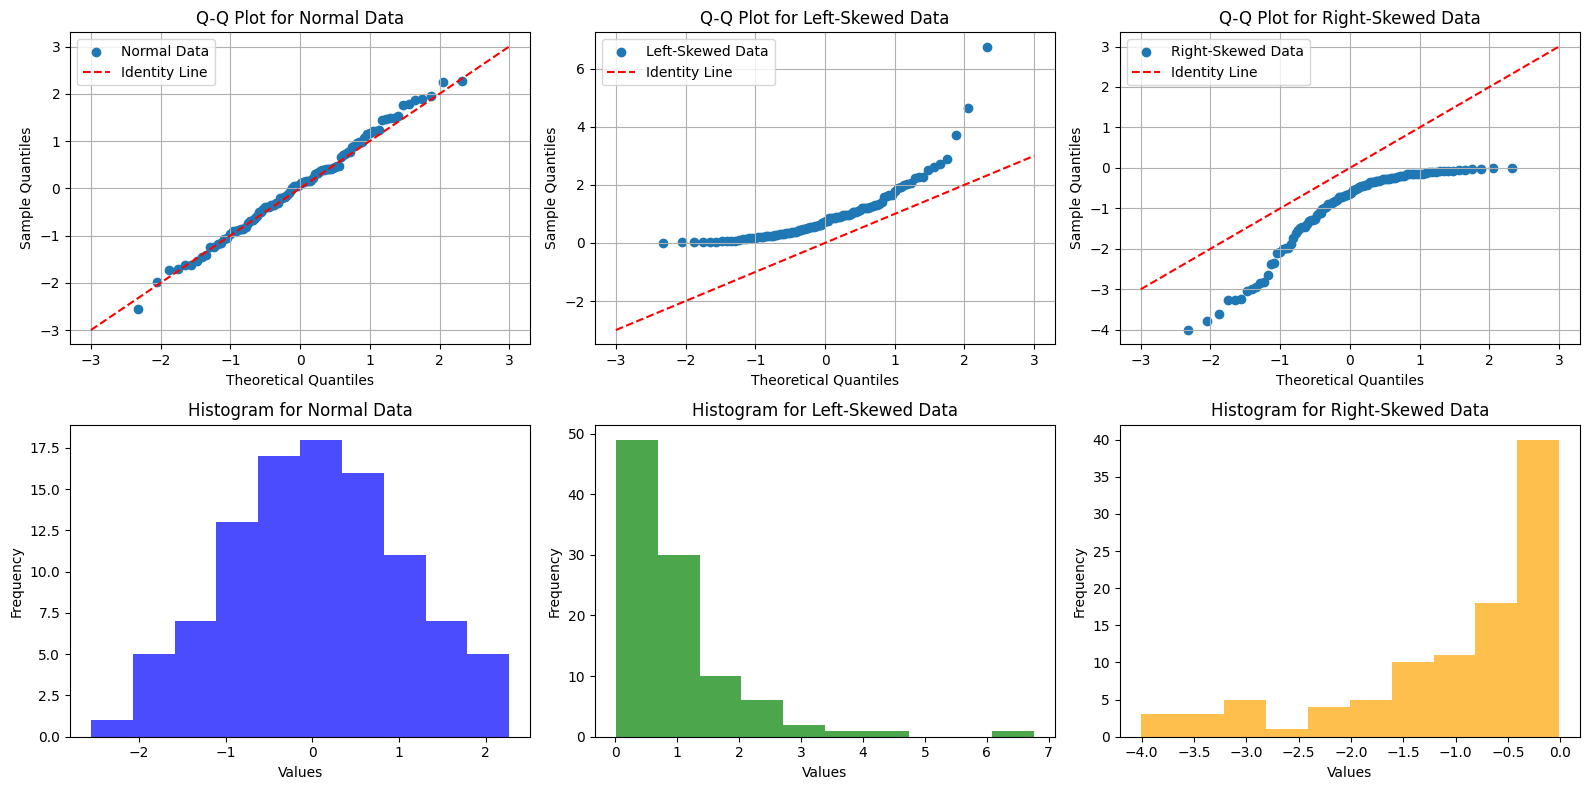

### **Kolmogorov-Smirnov Test**
Kolmogorov-Smirnov Test is a non-parametric statistical test used to determine whether a sample of data comes from a particular probability distribution

**Formulate Hypotheses**:

- **Null Hypothesis (H0)**: The sample data follows the specified theoretical distribution.
- **Alternative Hypothesis (H1)**: The sample data does not follow the specified theoretical distribution.

**Calculate the Test Statistic (D)**:
$$
D = \max_{1\leq i\leq N} \left| F(Y_i) - \frac{i-1}{N}, \frac{i}{N} - F(Y_i) \right|
$$


- The test statistic, denoted as "**D**," is a measure of the maximum absolute difference between the empirical distribution function (EDF) of your sample data and the cumulative distribution function (CDF) of the specified theoretical distribution.
-**F** is the theoretical cumulative distribution of the distribution being tested, which must be a continuous distribution


**Determine the Critical Value or p-value**:

- The critical value for the KS test depends on the significance level (alpha) chosen for the test and the sample size. You can find these critical values in tables or use software tools to calculate them.
- Alternatively, you can calculate the p-value associated with the test statistic **D**. The p-value is the probability of observing a test statistic as extreme as **D**, assuming that the null hypothesis is true.

**Compare D to Critical Value or p-value**:

- If the calculated **D** statistic exceeds the critical value or if the p-value is less than your chosen significance level (alpha), you reject the null hypothesis.
- If **D** is less than the critical value or the p-value is greater than alpha, you fail to reject the null hypothesis, indicating that there is no significant difference between your sample data and the specified distribution.



#### **Code demonstration of KS test**


In [ ]:
import numpy as np
from scipy import stats

# Generate a sample dataset (you can replace this with your own data)
np.random.seed(4)  # For reproducibility
sample_data = np.random.normal(0, 1, 100)  # Generating a sample of 100 data points from a normal distribution

# Define the theoretical distribution (in this case, the normal distribution)
theoretical_distribution = stats.norm(0, 1)  # Mean = 0, Standard Deviation = 1

# Perform the KS test
D, p_value = stats.kstest(sample_data, theoretical_distribution.cdf)

# Set the significance level
alpha = 0.05

# Compare the test statistic to the critical value or p-value
if p_value < alpha:
    print(f"Reject the null hypothesis. The sample does not follow a normal distribution (p-value = {p_value})")
else:
    print(f"Fail to reject the null hypothesis. The sample follows a normal distribution (p-value = {p_value})")


Fail to reject the null hypothesis. The sample follows a normal distribution (p-value = 0.556912779793759)


### **Chi Squared Test**

The chi-squared goodness-of-fit test is a statistical test used to determine whether the observed distribution of a categorical variable differs significantly from a theoretically expected distribution. This test is often applied when you have a single categorical variable with more than two categories, and you want to check if the observed frequencies match some expected distribution




### Steps to Perform a Chi-Squared Goodness-of-Fit Test

1. **Formulate the Hypotheses**:
   - Null Hypothesis (H0): The observed data follows the expected distribution.
   - Alternative Hypothesis (H1): The observed data does not follow the expected distribution.

2. **Collect Data and Create Categories**:
   - Collect your data and organize it into categories. For example, you might be interested in testing whether the observed distribution of colors of cars on a car lot matches the expected distribution (e.g., 30% red, 40% blue, 20% green, 10% yellow).

3. **Determine Expected Frequencies**:
   - Calculate the expected frequencies for each category based on the null hypothesis. In the car example, you would calculate how many cars are expected in each color category based on the expected percentages.

4. **Create a Contingency Table**:
   - Create a contingency table that lists the observed and expected frequencies for each category.


<div align="center">
  <table>
    <tr>
      <th>Category</th>
      <th>Observed Frequency (O)</th>
      <th>Expected Frequency (E)</th>
    </tr>
    <tr>
      <td>Red</td>
      <td>O1</td>
      <td>E1</td>
    </tr>
    <tr>
      <td>Blue</td>
      <td>O2</td>
      <td>E2</td>
    </tr>
    <tr>
      <td>Green</td>
      <td>O3</td>
      <td>E3</td>
    </tr>
    <tr>
      <td>Yellow</td>
      <td>O4</td>
      <td>E4</td>
    </tr>
  </table>
</div>



5. **Calculate the Chi-Squared Test Statistic (χ²)**:
   - Use the formula to calculate the chi-squared test statistic:

   $$
   \chi^2 = \sum \frac{(O - E)^2}{E}
   $$

   Where Σ represents the sum across all categories.

6. **Determine Degrees of Freedom (df)**:
   - The degrees of freedom for a goodness-of-fit test is usually equal to the number of categories minus 1. In the example above, df would be 4 - 1 = 3.

7. **Set the Significance Level (α)**:
   - Choose a significance level, such as 0.05, to determine if the results are statistically significant.

8. **Find the Critical Value**:
   - Use a chi-squared distribution table or a statistical software package to find the critical value for your chosen significance level and degrees of freedom.

9. **Compare the Calculated χ² Value to the Critical Value**:
   - If the calculated χ² value is greater than the critical value, reject the null hypothesis. This means that the observed distribution significantly differs from the expected distribution.

10. **Interpret the Results**:
    - Based on your comparison in step 9, you can draw conclusions about whether the observed data matches the expected distribution.

If you reject the null hypothesis, it suggests that there is a significant difference between the observed and expected distributions, indicating that the variable of interest is not distributed as expected. If you fail to reject the null hypothesis, it suggests that there is no significant difference, and the observed data follows the expected distribution.


## **Non Parametric Density Estimation**

Non-parametric density estimation is a statistical technique used to estimate density of a underlying distribution without making strong distributional assumptions. Non Parametric Density Estimation makes few assumptions about the density function and allow the data to control the estimation process more directly.


# **Advantages of non parametric density estimation**

1. **Flexibility:** Non-parametric methods are flexible and can adapt to a wide range of data distributions, making them suitable for situations where the true underlying distribution is unknown or complex.

2. **Data-Driven:** Non-parametric density estimation methods rely on the information contained within the dataset to estimate the density.

3. **Smoothness Control:** Some non-parametric methods, like Kernel Density Estimation (KDE), allow you to control the smoothness of the estimated density through bandwidth selection. This provides a balance between capturing details and reducing noise




# **Disadvantages of non parametric density estimation**

1. **Computationally Intensive:** Some non-parametric methods can be computationally intensive, especially with large datasets or high-dimensional data.

2. **Assumption of Independence:** Some non-parametric methods assume that data points are independent, which may be true for all cases(e.g., time series data).

3. **Hypothesis Testing and Inference**: Non Parametric models are not as quick as hypothesis testing and inference as Parametric models

# **Historgram ( Example of Non parametric density estimation)**

Histograms allows to estimate the probability disribution P<sub>data</sub> from a set of observed data sample x(1) , x(2) , ..., x(n) .This means you want to determine the probabilities of each possible value in the set {1,...,k}





# **How to train a histogram model**
To train a histogram model we need to count the probabilities P<sub>i</sub> for each value i in set {1,...,k}. This is done by counting how many times each value appears in a dataset and dividing by total number of points in the dataset(n)

# **Calculating probabilties of Histogram model**
Once the histogram model is trained you can estimate the probabilites P<sub>i</sub>


$$ P(i) = \frac{\text{number of times "i" appears in the dataset}}{\text{total number of points in the dataset}} $$

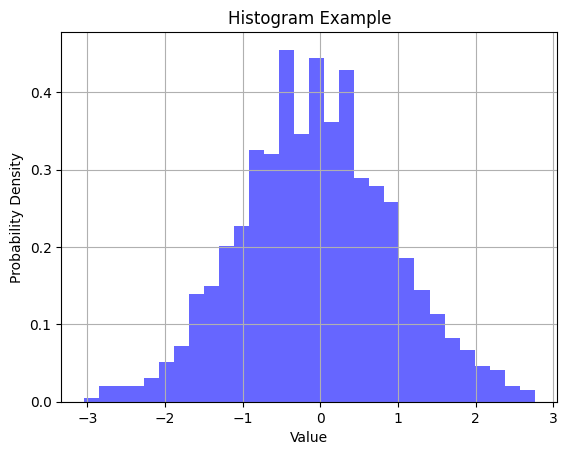

# **Using a Histogram model**

Histogram model can be used for **Inference** and **Sampling**

 ## **Inference**
Inference is like looking up information from a list. For example you have alist of numbers from P<sub>1</sub>,P<sub>2</sub>,P<sub>3</sub>...P<sub>k</sub>. Each number represent a chance of raining on a day.If you want to know the chance of rain on a specific day 3 just look at the number P<sub>3</sub>


## **Sampling**
Sampling is like making a random choice based on a list of probabilities. Let's say you have a list of probabilities: P<sub>1</sub>,P<sub>2</sub>,P<sub>3</sub>...P<sub>k</sub> and each probability represents the chance of something happening, like winning a prize in a game.

### **Example of Sampling**
For example, if you have three events with probabilities P<sub>1</sub>,P<sub>2</sub>,P<sub>3</sub> and you calculate their cumulative probabilities F1, F2, and F3, and you get something like F1 = 0.2, F2 = 0.5, F3 = 0.2, and your random number "U" is 0.4, you'd choose event 2 because 0.4 is less than F2 (0.4 < 0.5).

So, sampling is like making a random decision based on the likelihood of different events happening, using the probabilities you have in your list.

#**Code Demonstration of Sampling and Inference**



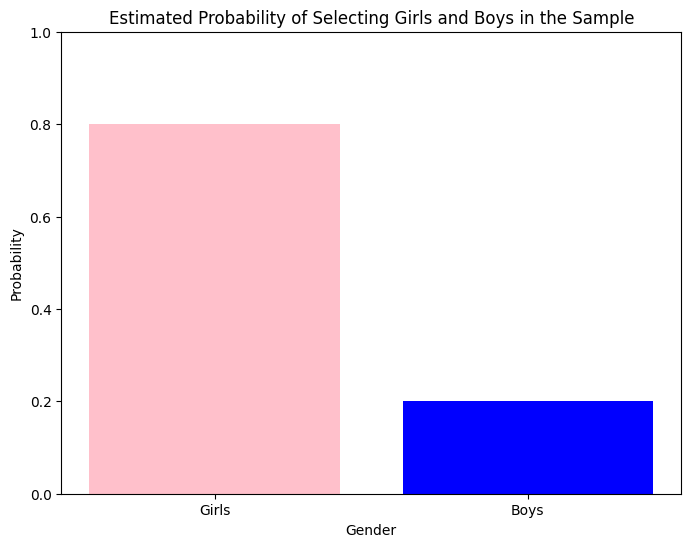

In [ ]:
import random
import matplotlib.pyplot as plt

# Population data: 75 girls and 25 boys in a class of 100 students
total_students = 100
girls_count = 75
boys_count = 25

# Probability of selecting a girl or a boy
probability_girl = girls_count / total_students
probability_boy = boys_count / total_students

# Number of students to sample
sample_size = 35

# Perform random sampling
sampled_students = random.sample(range(1, total_students + 1), sample_size)

# Count the number of girls and boys in the sample
girls_in_sample = sum(1 for student in sampled_students if student <= girls_count)
boys_in_sample = sample_size - girls_in_sample

# Calculate the estimated probabilities based on the sample
estimated_probability_girl = girls_in_sample / sample_size
estimated_probability_boy = boys_in_sample / sample_size

# Visualize the estimated PDF and histogram
labels = ['Girls', 'Boys']
probabilities = [estimated_probability_girl, estimated_probability_boy]

# Bar chart for the estimated probabilities
plt.figure(figsize=(8, 6))
plt.bar(labels, probabilities, color=['pink', 'blue'])
plt.title('Estimated Probability of Selecting Girls and Boys in the Sample')
plt.xlabel('Gender')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.show()


# **Problem with Histogram**

### **Curse of Dimesionality**  
Histogram does not work properly for high-dimensional data

**Example**

Consider a 28 X 28 image(like a MNIST image)

Each pixel in the image can be either 0 or 1, which gives you 2<sup>784</sup> possible combinations (about 10<sup>236</sup> , an incredibly large number) for such images
To estimate probabilities for each of these combinations, you'd need a tremendous amount of data, and in practice, you can't collect data for all possible combinations. Even in case of MNIST dataset there are 60,000images which would still not be enough

### **Problem even in 1 Dimensional data**

Even in case of 1D data if there are many values the histogram is prone to fitting.




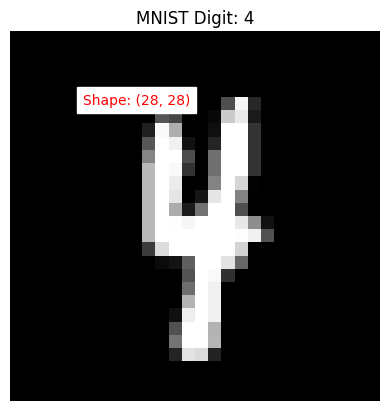

# **Kernel Density Estimation**

Kernel Density Estimation (KDE) is a non-parametric density estimation method used for estimating the probability density function (PDF) of a continuous random variable

$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^n K\left(\frac{x - x_i}{h}\right)$$

Kernel Density Estimation (KDE) is a method that involves using a kernel function (typically a smooth, symmetrical function like a Gaussian) and a smoothing bandwidth parameter (h > 0). It works by taking each data point (Xᵢ) and creating a small, smoothed density bump. These individual bumps are then added together to produce the overall density estimate.








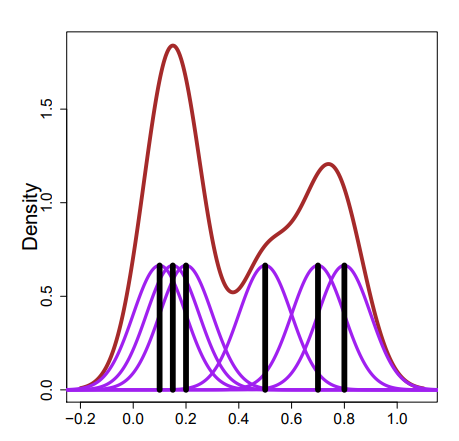

 Source - University of Washington. (2018). Lecture 6: Histograms and Kernel Density Estimation. [PDF](https://faculty.washington.edu/yenchic/18W_425/Lec6_hist_KDE.pdf)



 In the provided image, there are six data points indicated by black vertical segments positioned at 0.1, 0.2, 0.5, 0.7, 0.8, and 0.15. The Kernel Density Estimation (KDE) process begins by transforming each of these data points into individual purple density bumps. These individual density bumps are then combined or summed together to create the final representation of the data's density, which is depicted as the brown density curve.



## **Effect of different Bandwidth Parameter (h) in Kernel Density Estimation**

The kernel has a bandwidth (also called the smoothing parameter or bandwidth parameter). This parameter controls the spread or width of the kernel. A smaller bandwidth results in a more sensitive KDE estimate, capturing finer details in the data, while a larger bandwidth results in a smoother estimate with fewer details. The choice of bandwidth is a crucial decision in KDE and can affect the final result


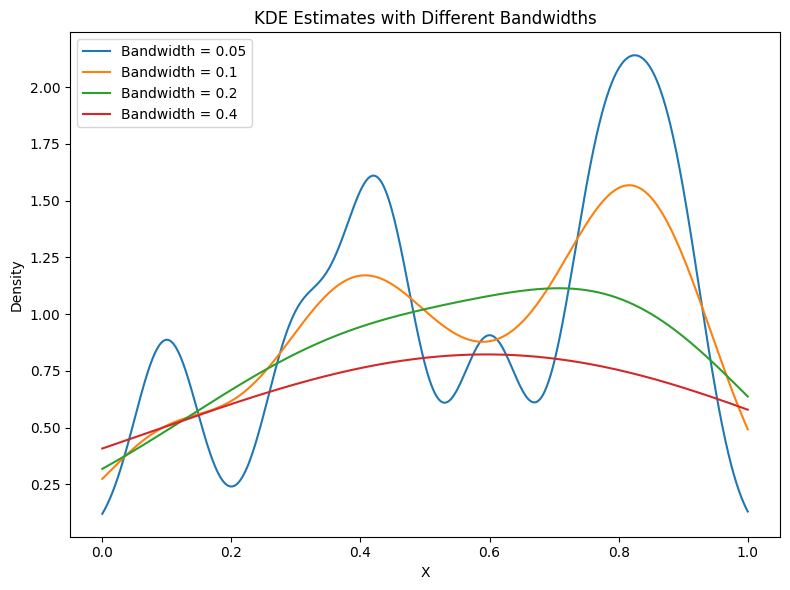

The figure above shows how different bandwidth values impact the Kernel Density Estimation (KDE) for a set of data points.

**Bandwidth = 0.05 (Blue Curve):**

- A very small bandwidth results in a high level of sensitivity.
- The KDE closely follows the data points, creating wiggly structures in the density curve.
- Fine details and local variations in the data are captured but may also be sensitive to noise. The density curve is not as smooth as with larger bandwidths.

**Bandwidth = 0.1 (Orange Curve):**

- A moderate bandwidth provides a balance between sensitivity and smoothness.
- The KDE captures most of the prominent features in the data, and the curve is smoother compared to the smaller bandwidth.
- Local variations are still noticeable, but the density estimate is less wiggly and more stable.

**Bandwidth = 0.2 (Green Curve):**

- Increasing the bandwidth further leads to a smoother KDE estimate.
- The density curve becomes more generalized and is less sensitive to fine details in the data.
- Some of the local variations are smoothed out, and the overall shape of the density estimate is more consistent.

**Bandwidth = 0.4 (Red Curve):**

- A large bandwidth results in a significant level of smoothing.
- The KDE creates a highly generalized estimate, with little sensitivity to local data variations.
- The two peaks in the data become less pronounced, and the density estimate is smoother but may lose important structural features.

In summary, Smaller bandwidths capture fine-grained details but may be sensitive to noise, while larger bandwidths result in smoother estimates but can obscure important data structures. The optimal bandwidth depends on the specific dataset and the goal of the analysis. This figure illustrates the trade-off between sensitivity and smoothness when choosing different bandwidth values for KDE.


## **Methods of choosing Bandwidth Parameter**

1. **Silverman’s rule of thumb** computes an optimal h by assuming that
the data is normally distributed. Which is a good starting point in many cases.



2. **The Improved Sheather Jones (ISJ)**algorithm is a modification of the Sheather Jones (SJ) algorithm used for selecting the bandwidth parameter in Kernel Density Estimation (KDE).

*Initialization:*

1. Start with a small bandwidth value (h_min), often set to a fraction of the standard deviation of the data.

*Iterative Procedure:*

2. Define a sequence of bandwidths, each increasing by a multiplicative factor, e.g., doubling: h_i = 2 * h_(i-1).
3. For each bandwidth h_i:
   - Calculate the KDE with bandwidth h_i.
   - Compute a Cross-Validation (CV) score:
     - Use a suitable CV method (e.g., leave-one-out cross-validation) to estimate the Mean Integrated Squared Error (MISE) of the KDE for the given bandwidth h_i.
   - Track the minimum CV score:
     - Maintain the bandwidth h_min that yields the minimum CV score.

*Refine the Search:*

4. Consider a more fine-grained search in the vicinity of h_min. This could involve evaluating bandwidths in a smaller range around h_min.

*Final Bandwidth Selection:*

5. The final selected bandwidth is often the h_min that minimizes the CV score.


# **Various Kernel Functions**
The kernel function does not play a key role. But sometimes in practice,
they do show some difference in the density estimator. The figure below shows different types of Kernerl Functions



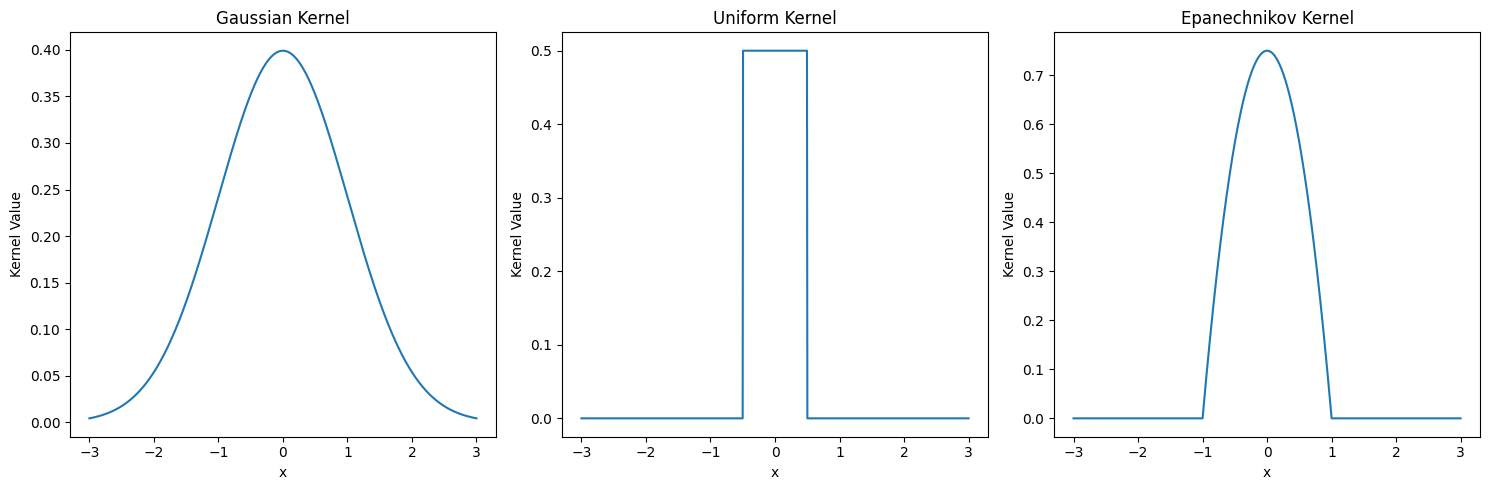

*Figure- Various Kernel Functions*

## **Code Demonstration for KDE**

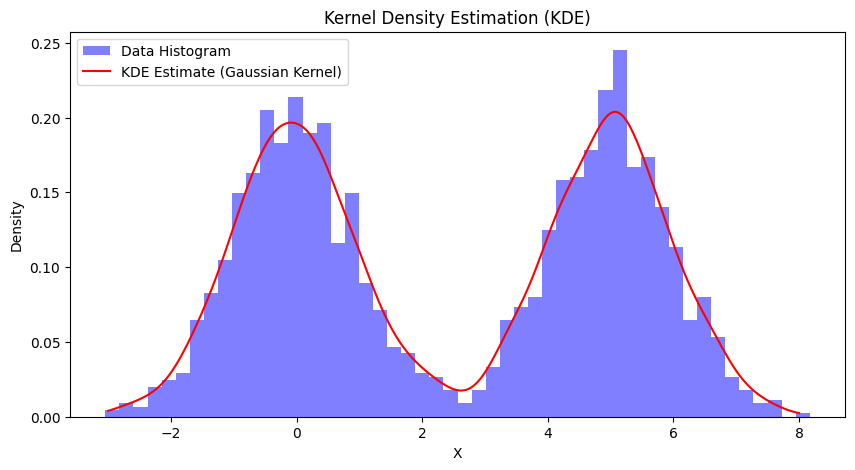

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

# Generate a sample dataset (you can replace this with your own data)
np.random.seed(0)
data = np.concatenate([np.random.normal(0, 1, 1000), np.random.normal(5, 1, 1000)])

# Create a range of x values for the density plot
x = np.linspace(-3, 8, 1000)

# Fit a KDE to the data using cross-validation for bandwidth selection
bandwidths = 10 ** np.linspace(-1, 1, 100)

# Perform a grid search for the optimal bandwidth
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths},
                    cv=10)  # 10-fold cross-validation for bandwidth selection
grid.fit(data[:, None])

# Get the best bandwidth from the grid search
best_bandwidth = grid.best_estimator_.bandwidth

# Create a KDE model with the optimal bandwidth
kde = KernelDensity(bandwidth=best_bandwidth, kernel='gaussian')

# Fit the KDE model to the data
kde.fit(data[:, None])

# Calculate the log-density for the given x values
log_dens = kde.score_samples(x[:, None])

# Plot the data and the KDE estimate
plt.figure(figsize=(10, 5))
plt.hist(data, bins=50, density=True, alpha=0.5, color='blue', label='Data Histogram')
plt.plot(x, np.exp(log_dens), color='red', label='KDE Estimate (Gaussian Kernel)')

# Add labels and title to the plot
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Kernel Density Estimation (KDE)')

# Add a legend to the plot
plt.legend()

# Show the plot
plt.show()


**Bandwidth Selection Using Cross-Validation:**

- `bandwidths`: Defines a range of bandwidth values to consider for the KDE.
- `GridSearchCV`: Performs a grid search to find the optimal bandwidth for the KDE. It uses 10-fold cross-validation to assess bandwidth performance.
- The search is done with a Gaussian kernel (`kernel='gaussian'`) to find the best bandwidth.

**Fitting the KDE Model:**

- `best_bandwidth`: Extracts the optimal bandwidth found during the grid search.

**Kernel Density Estimation:**

- `kde`: Creates a KDE model with the optimal bandwidth and a Gaussian kernel.
- `kde.fit(data[:, None])`: Fits the KDE model to the sample data, reshaping data to a column vector using `data[:, None]`.

**Calculating Log-Density:**

- `log_dens`: Computes the log-density for the x values using the fitted KDE model. This step estimates the probability density at each x value.


## **Mathematical Theory for KDE**

### **Bias of KDE**

1. Start with the KDE estimate:

$$
\hat{f}_h(x_0) = \frac{1}{n} \sum_{i=1}^{n} K\left(\frac{x_i - x_0}{h}\right)
$$

2. Compute the expected value of the KDE estimate:

$$
E(\hat{f}_h(x_0)) = E\left(\frac{1}{n} \sum_{i=1}^{n} K\left(\frac{x_i - x_0}{h}\right)\right) = \frac{1}{n} \sum_{i=1}^{n} E\left(K\left(\frac{x_i - x_0}{h}\right)\right)
$$

3. Use Taylor expansion for the kernel function:

$$
K(u) = K(0) + uK'(0) + \frac{1}{2}u^2K''(0) + o(u^2)
$$

4. Plug the Taylor expansion into the expectation:

$$
E\left(K\left(\frac{x_i - x_0}{h}\right)\right) = E\left(K(0) + \frac{x_i - x_0}{h}K'(0) + \frac{1}{2}\left(\frac{x_i - x_0}{h}\right)^2K''(0) + o\left(\left(\frac{x_i - x_0}{h}\right)^2\right)\right) = K(0) + o\left(\frac{1}{h^2}\right)
$$

5. Now, plug this result back into the expected value of the KDE estimate:

$$
E(\hat{f}_h(x_0)) = \frac{1}{n} \sum_{i=1}^{n} \left(K(0) + o\left(\frac{1}{h^2}\right)\right) = K(0) + o\left(\frac{1}{h^2}\right)
$$

6. The constant term $K(0)$ is not important in the bias calculation, so we can ignore it. Therefore, we have:

$$
\text{bias}(\hat{f}_h(x_0)) = o\left(\frac{1}{h^2}\right)
$$

7. Introduce the second derivative term:

$$
\text{bias}(\hat{f}_h(x_0)) = \frac{1}{2} h^2 f''(x_0) \mu_K + o(h^2)
$$

Where $\mu_K$ is a constant that depends on the kernel function and is related to the integral of the square of the kernel function.




## **KNN for Non parametric density estimation**

The k-Nearest Neighbor (k-NN) density estimator is a non-parametric method used to estimate the probability density function (PDF) of a continuous random variable. It works by considering the k data points that are nearest to a given point and using their distances to estimate the local density at that point.

Imagine you have a bunch of data points, each with multiple characteristics (variables). Now, pick one specific point, call it 'x.' What we're going to do is look at all the data points and figure out which ones are closest to 'x.' We'll rank them based on their closeness to 'x,' so the closest point will be ranked first, the second closest second, and so on. These rankings are represented by R<sub>k</sub>(x), where 'k' stands for how far down the list of closest points we're going.

So, in a nutshell, we're just figuring out how close the data points are to our chosen point 'x' and ranking them based on that closeness.







## **Math behind KNN for Density Estimation**

For a given point x, the kNN density estimator estimates the density by:
$$
p_{bknn}(x) = \frac{k}{n} \cdot \frac{1}{V_d \cdot R_d^k(x)}
$$
Where:
- V<sub>d</sub> is the volume of a d-dimensional ball with a radius of R<sub>k</sub>(x).
$$
V_d = \frac{\pi^{d/2} }{\Gamma\left(\frac{d}{2} + 1\right)}
$$
, where Γ(x) is the Gamma function.

The results for different dimensions d (d = 1, 2, and 3) are as follows:

- For d = 1, V1 = 2:
 $$p_{bknn}(x) = \frac{k}{n} \cdot \frac{1}{2 \cdot R_k(x)}
$$.
- For d = 2, V2 = π:
$$p_{bknn}(x) = \frac{k}{n} \cdot \frac{1}{\pi \cdot R_{k}^2(x)}
$$
- For d = 3, V3 = 4/3 * π:
$$
p_{bknn}(x) = \frac{k}{n} \cdot \frac{1}{4 \pi \cdot R_{k}^3(x)}
$$

 By the definition of Rk(x), the ball centered at x with
radius R<sub>k</sub>(x)
$$
B(x, R_k(x)) = {y : ||x - y|| ≤ Rk(x)}
$$

$$
\frac{k}{n} = \frac{1
}{n} \sum_{i=1}^{n} I(X_i \in B(x, R_k(x)))
$$

This means that the proportion of observations within the ball B(x, R<sub>k</sub>(x) is k/n.

Recalling the relation between the Empirical Distribution Function (EDF) and Cumulative Distribution Function (CDF), the quantity:
$$
\frac{1}{n} \sum_{i=1}^{n} I(X_i \in B(x, R_k(x)))
$$
Can be viewed as an estimator of the quantity:

$$
P(X_i \in B(x, R_k(x))) \approx \int_{B(x, R_k(x))} p(y) dy
$$

# **Code demonstration for K nearest Neighbour**

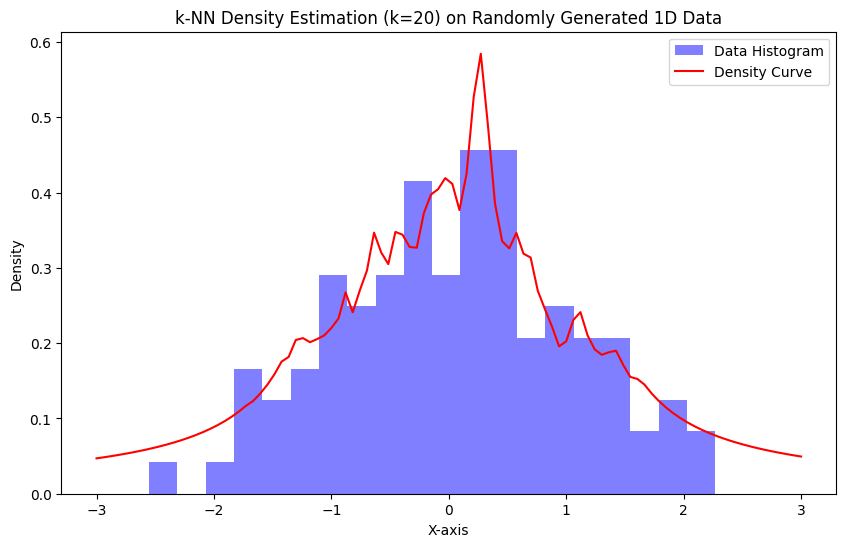

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a random 1D dataset
np.random.seed(0)
data = np.random.randn(100)

def kNN_density_estimator(data, x, k):
    # Calculate the distance from x to each data point
    distances = np.abs(data - x)

    # Sort distances and get the kth nearest neighbor's distance
    kth_distance = np.partition(distances, k-1)[k-1]

    # Calculate the kNN density estimate
    n = len(data)
    vd = 2.0
    density_estimate = (k / n) / (vd * kth_distance)

    return density_estimate

# Choose the number of neighbors (k)
k = 20

# Create a grid of points for visualization
x_range = np.linspace(-3, 3, 100)

# Calculate the kNN density estimate for each point in the grid
density_estimates = np.array([kNN_density_estimator(data, point, k) for point in x_range])

# Visualize the density estimates using a histogram for the data and a density curve
plt.figure(figsize=(10, 6))
plt.hist(data, bins=20, density=True, alpha=0.5, color='blue', label='Data Histogram')
plt.plot(x_range, density_estimates, color='red', label='Density Curve')
plt.xlabel('X-axis')
plt.ylabel('Density')
plt.title(f'k-NN Density Estimation (k={k}) on Randomly Generated 1D Data')
plt.legend()
plt.show()




`kNN_density_estimator(data, x, k)`: This function calculates the k-NN density estimate for a given data point `x` with a specified number of neighbors `k`. It operates as follows:

- It calculates the absolute differences between `x` and each data point.
- Sorts these distances and selects the `k`-th nearest neighbor's distance.
- Computes the density estimate using the formula `(k / n) / (vd * kth_distance)`, where `n` is the number of data points, `vd` is the volume of a 1D unit ball (which is simply 2), and `kth_distance` is the distance to the `k`-th nearest neighbor.

**Visualization:**

- `k = 20`: This sets the number of neighbors to be considered in the k-NN density estimation.
- `x_range = np.linspace(-3, 3, 100)`: It creates a range of points on the x-axis where you want to estimate the density.







## **Different Values of K in Knn**

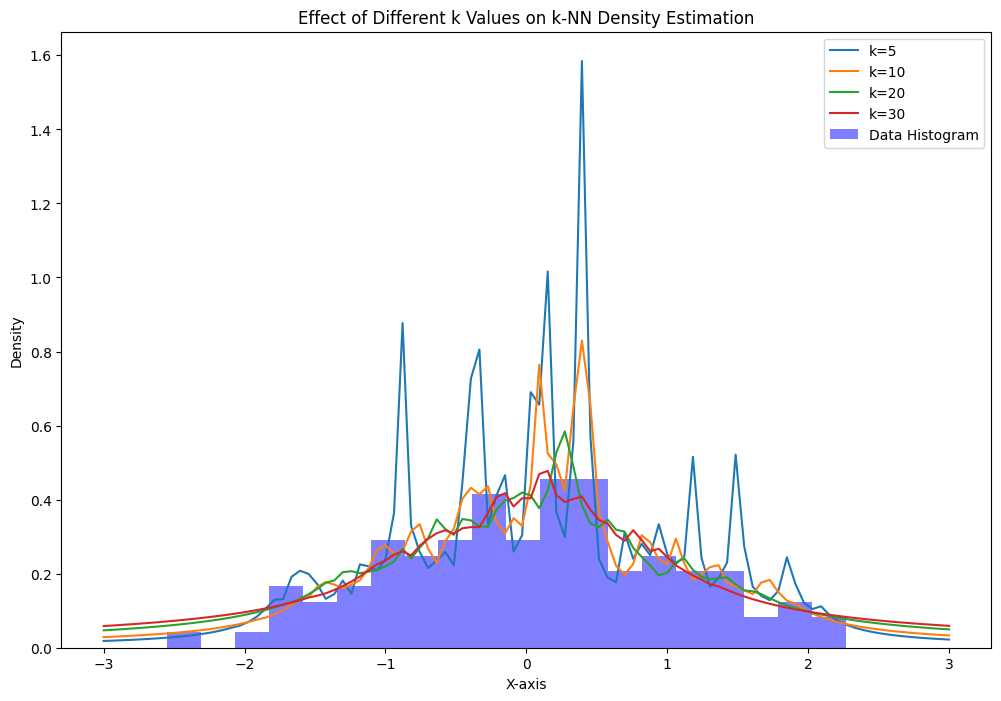

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a random 1D dataset
np.random.seed(0)
data = np.random.randn(100)

def kNN_density_estimator(data, x, k):
    # Calculate the distance from x to each data point
    distances = np.abs(data - x)

    # Sort distances and get the kth nearest neighbor's distance
    kth_distance = np.partition(distances, k-1)[k-1]

    # Calculate the kNN density estimate
    n = len(data)
    vd = 2.0
    density_estimate = (k / n) / (vd * kth_distance)

    return density_estimate

# Define different values of k to test
k_values = [5, 10, 20, 30]

# Create a grid of points for visualization
x_range = np.linspace(-3, 3, 100)

# Create subplots for each k value
plt.figure(figsize=(12, 8))
for k in k_values:
    density_estimates = np.array([kNN_density_estimator(data, point, k) for point in x_range])
    plt.plot(x_range, density_estimates, label=f'k={k}')

# Visualize the density estimates using a histogram for the data
plt.hist(data, bins=20, density=True, alpha=0.5, color='blue', label='Data Histogram')
plt.xlabel('X-axis')
plt.ylabel('Density')
plt.title('Effect of Different k Values on k-NN Density Estimation')
plt.legend()
plt.show()


**Smoothing Effect:**

- Smaller `k` values (e.g., k=5) lead to sharper and more localized density estimates.
  - These density estimates are sensitive to local variations in the data. They capture fine-grained details and exhibit more variability.
- Larger `k` values (e.g., k=30) result in smoother and more generalized density estimates.
  - They are less influenced by local fluctuations and provide a more generalized view of the underlying distribution.

**Bias and Variance Trade-off:**

- Smaller `k` values tend to introduce more bias because they emphasize the contribution of a limited number of nearest neighbors. This can lead to overfitting, capturing noise in the data.
- Larger `k` values tend to have lower bias but higher variance because they consider more neighbors. This results in a smoother estimate but may miss local variations in the data.

**Choice of `k`:**

- The optimal choice of `k` depends on the specific characteristics of the data and the objectives of the analysis.
- Smaller `k` values are suitable when you want to capture fine-grained structures and local features in the data.
- Larger `k` values are preferred when you seek a more generalized and robust estimate that smooths out noise.


# Comparision of various of Parametric and Non parametric Models

| Type          | Method               | Convergence rate | Tuning parameter | Limitation                     |
|---------------|----------------------|-------------------|------------------|---------------------------------|
| Parametric   | Parametric model     | O(√1/n)           | None             | Unavoidable bias                |
| Parametric   | Mixture model        | O(√1/n)           | K, number of mixture | Hard to compute              |
| Nonparametric | Histogram            | O(1/n^(1/3))      | b, bin size      | Lower convergence rate         |
| Nonparametric | Kernel density estimator | O(1/n^(2/5)) | h, smoothing bandwidth |                            |
| Nonparametric | K-nearest neighbor    | O(1/n^(2/5))    | k, number of neighbor |                   |
| Nonparametric | Basis approach        | O(1/n^(2/5))     | M, number of b   |                          |


*Note - there are far more other density estimators but due to the time constraint, we cannot cover other*

# **Parametric vs Non Parametric Density Estimation**

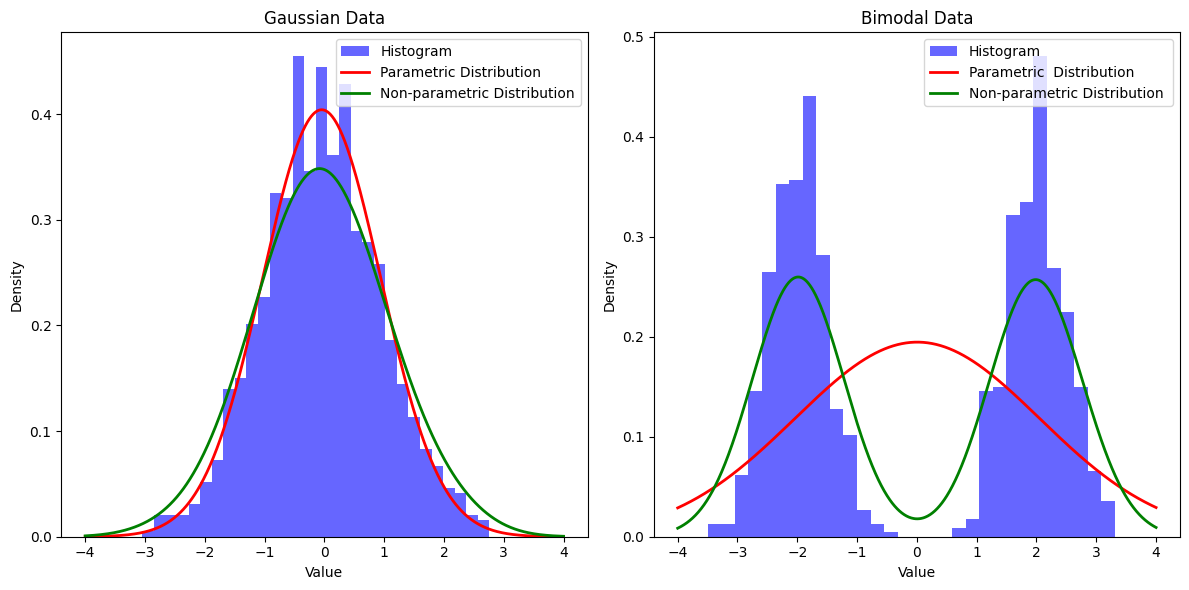

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity

# Generate synthetic data
np.random.seed(0)
data_gaussian = np.random.normal(0, 1, 1000)  # Gaussian data
data_bimodal = np.concatenate([np.random.normal(-2, 0.5, 500), np.random.normal(2, 0.5, 500)])  # Bimodal data

# Parametric (Gaussian) estimation for Gaussian data
mu, std = norm.fit(data_gaussian)

# Non-parametric (Kernel Density Estimation) for Gaussian data
kde = KernelDensity(bandwidth=0.6, kernel='gaussian')
kde.fit(data_gaussian.reshape(-1, 1))
x_grid = np.linspace(-4, 4, 1000)
kde_gaussian_estimation = np.exp(kde.score_samples(x_grid.reshape(-1, 1)))

# Parametric (Gaussian) estimation for bimodal data
mu_bimodal, std_bimodal = norm.fit(data_bimodal)

# Non-parametric (Kernel Density Estimation) for bimodal data
kde_bimodal = KernelDensity(bandwidth=0.6, kernel='gaussian')
kde_bimodal.fit(data_bimodal.reshape(-1, 1))
kde_bimodal_estimation = np.exp(kde_bimodal.score_samples(x_grid.reshape(-1, 1)))

# Plot results
plt.figure(figsize=(12, 6))

# Gaussian Data
plt.subplot(1, 2, 1)
plt.hist(data_gaussian, bins=30, density=True, alpha=0.6, color='b', label='Histogram')
plt.plot(x_grid, norm.pdf(x_grid, mu, std), 'r', linewidth=2, label='Parametric Distribution')
plt.plot(x_grid, kde_gaussian_estimation, 'g', linewidth=2, label='Non-parametric Distribution')
plt.title('Gaussian Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

# Bimodal Data
plt.subplot(1, 2, 2)
plt.hist(data_bimodal, bins=30, density=True, alpha=0.6, color='b', label='Histogram')
plt.plot(x_grid, norm.pdf(x_grid, mu_bimodal, std_bimodal), 'r', linewidth=2, label='Parametric  Distribution')
plt.plot(x_grid, kde_bimodal_estimation, 'g', linewidth=2, label='Non-parametric Distribution ')
plt.title('Bimodal Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()



For the data with normal distribution, both parametric and non-parametric methods provide accurate density estimates.

For the bimodal data, the parametric Gaussian model fails to capture the bimodal nature of the distribution, resulting in a poor fit. In contrast, the non-parametric method can adapt to the bimodal distribution, providing a more accurate representation.

This demo illustrates how parametric methods may fail when the data distribution deviates from the assumed parametric form, whereas non-parametric methods can be more flexible and adapt to complex data distributions.

# **References**

 https://cs.dartmouth.edu/~wjarosz/publications/dissertation/appendixC.pdf

https://faculty.washington.edu/yenchic/18W_425

https://towardsdatascience.com/kolmogorov-smirnov-test-84c92fb4158d

https://library.virginia.edu/data/articles/understanding-q-q-plots#:~:text=A%20QQ%20plot%20is%20a,a%20line%20that's%20roughly%20straight.
